# CorrDiff — Generative Downscaling for Km-Scale Weather
### A complete walkthrough: theory → architecture → installation → case study

**Paper:** Mardani, Brenowitz, Cohen, et al. (NVIDIA / Central Weather Administration, Taiwan), *"Residual Corrective Diffusion Modeling for Km-scale Atmospheric Downscaling,"* arXiv:2309.15214 (2024).

**What this notebook does:**
1. Explains *why* CorrDiff exists and the physics/ML problem it solves (no implementation, just intuition — for your presentation slides)
2. Explains the architecture in detail: the two-step regression + diffusion design, the EDM diffusion math, the UNet
3. States the **hardware and data requirements**, and why they matter for where you can run this
4. Installs NVIDIA's `earth2studio` library on Colab and loads the **pretrained CorrDiff-Taiwan checkpoint** (no training needed — training this from scratch took 21,504 GPU-hours on H100s, which is not something you replicate in a notebook)
5. Runs a **real case study**: Typhoon Koinu (October 2023), downscaling live GFS forecast data from 25km to ~2km resolution over Taiwan
6. Produces plots and insights you can lift directly into your presentation

> **Run this on Colab with a T4 GPU** (Runtime → Change runtime type → T4 GPU). The model is small enough (~80M parameters) that this comfortably fits in a T4's 15GB of usable VRAM — this is the opposite situation from FourCastNet3, which needs ~60GB and cannot run on a T4 at all.


---
## Part 1 — What problem is CorrDiff solving?

### The core problem: weather models give you the wrong resolution for the question you're asking

Global weather models — ERA5 (a reanalysis dataset), GFS (NOAA's forecast model), or AI models like FourCastNet — operate on a grid roughly **25 km** on a side. That's fine for asking "will it rain somewhere in northern Taiwan tomorrow," but useless for asking "will this specific valley flood," because at 25 km resolution a single grid cell can contain an entire mountain range, several towns, and a coastline all averaged into one number.

To get to the resolution that actually matters for hazard prediction — **km-scale**, typically 1–3 km — meteorological agencies run **dynamical downscaling**: they take the coarse global forecast as a boundary condition and run a much more expensive, much higher-resolution physical simulation (a regional Numerical Weather Prediction model) nested inside it. In this paper, that's the WRF model run by Taiwan's Central Weather Administration (CWA), assimilating radar data, run on **928 CPU cores**.

This works, but it's expensive. You can't run an ensemble of hundreds of these to quantify uncertainty, and you can't do it everywhere, all the time.

**CorrDiff's proposal:** train a generative model to learn the *statistical mapping* from coarse input to fine output directly from historical examples of (coarse-input, fine-output) pairs, and use it as a cheap, fast stand-in for the physical downscaling simulation.

This is the same idea as the project you're working on (replacing FourCastNet3-style global forecasting with GenAI) — except CorrDiff operates one level down the pipeline: not "predict the future state of the atmosphere," but "given a forecast at 25km, sharpen it to 2km and add the physically realistic fine-scale detail that the coarse grid simply cannot represent."

### Why not just use a regular neural network (e.g. a CNN) for this?

You could. In fact, the paper trains exactly that as one of its baselines — a UNet trained with a standard Mean Squared Error (MSE) loss. The problem is fundamental, not a matter of more training:

**Downscaling is a one-to-many problem.** A single coarse-resolution input is consistent with *many* different physically plausible fine-resolution fields. The exact placement of a rain band, the precise wind gust pattern around a mountain ridge — these have a genuinely random, chaotic component at the km-scale that isn't determined by the 25km input.

If you train a network with MSE loss to predict the fine-scale field directly, the mathematically optimal thing for it to do is predict the **average** of all the plausible fine-scale outcomes. Averaging plausible-but-different rain bands gives you a *blurry, physically unrealistic smear* — not a sharp rain band in a slightly wrong place, but a faded, smoothed-out ghost of one. This is the single biggest reason regression-only models fail at this task: they are mathematically punished for being sharp and confidently wrong, and rewarded for being blurry and "safely" close to everything at once.

A **generative** model sidesteps this. Instead of predicting one deterministic output, it learns the full conditional probability distribution `p(fine-scale output | coarse-scale input)`, and you sample *one realistic, sharp, internally-consistent* realization from that distribution at a time. That's what diffusion models are for.


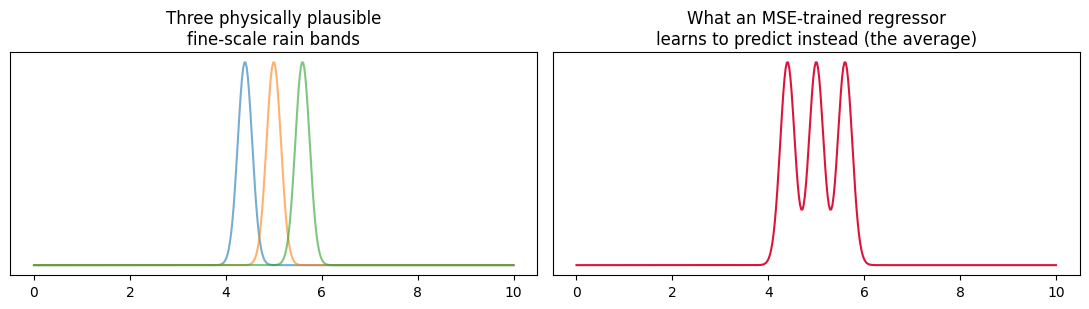

This is exactly the blur problem Section 1 describes -- MSE regression averages
plausible sharp outcomes into one blurry, unrealistic one. CorrDiff's diffusion
step exists specifically to restore this missing sharpness/variance.


In [1]:
# --- Visual intuition: why averaging plausible outcomes produces blur ---
# This is NOT part of CorrDiff -- it's a tiny illustration of the core problem.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.linspace(0, 10, 400)

# Three "plausible" sharp rain bands, each shifted slightly -- like three
# samples from the true conditional distribution p(x | coarse_input)
plausible_samples = []
for shift in [-0.6, 0.0, 0.6]:
    band = np.exp(-((x - 5 - shift) ** 2) / (2 * 0.15 ** 2))
    plausible_samples.append(band)

mse_optimal_prediction = np.mean(plausible_samples, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for s in plausible_samples:
    axes[0].plot(x, s, alpha=0.6)
axes[0].set_title("Three physically plausible\nfine-scale rain bands")
axes[0].set_yticks([])

axes[1].plot(x, mse_optimal_prediction, color="crimson")
axes[1].set_title("What an MSE-trained regressor\nlearns to predict instead (the average)")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()
print("This is exactly the blur problem Section 1 describes -- MSE regression averages")
print("plausible sharp outcomes into one blurry, unrealistic one. CorrDiff's diffusion")
print("step exists specifically to restore this missing sharpness/variance.")


### CorrDiff's specific trick: don't generate the whole field — generate the *residual*

You could imagine training a diffusion model to generate the full high-resolution field directly, conditioned on the coarse input. The authors tried this first and it worked poorly — slow to converge, and the generated images had incoherent structure. Why? Diffusion models work by destroying a signal with noise and learning to reverse that process. If the signal you're trying to generate (raw radar reflectivity at 2km) is very "loud" — high dynamic range, very different statistics from the smooth input — you need a lot of noise and a lot of denoising steps to make it work, and that hurts both training and sample quality.

So CorrDiff splits the job into two networks that each do an *easier* sub-task:

$$x = \underbrace{\mathbb{E}[x \mid y]}_{\mu \text{ — regression}} + \underbrace{(x - \mathbb{E}[x \mid y])}_{r \text{ — generative correction}}$$

- **`y`** = the coarse 25km input (12 channels — see Part 3 for exactly what these are)
- **`x`** = the true fine 2km target field (4 channels)
- **`μ`** = a UNet trained with plain MSE regression to predict the **conditional mean** — i.e., its best single-number guess. This step is allowed to be blurry; it's only responsible for getting the large-scale structure right (where's the front, where's the typhoon center).
- **`r`** = the **residual** — what's left over after you subtract the mean prediction from the truth. This is what the diffusion model learns to generate.

This is directly analogous to **Reynolds decomposition** in fluid dynamics, where you split a turbulent flow into a mean component and a fluctuating component and model each separately — which is a framing your research audience (atmospheric scientists) will immediately recognize.

**Why does this help?** Two reasons, both provable from the structure of the variance:

$$\text{var}(r) = \mathbb{E}[\text{var}(x \mid y)] \;\le\; \text{var}(x)$$

1. **The residual has lower variance than the raw target**, especially when the mean prediction explains a lot of the variability (e.g. typhoons, where most of the field's variance comes from "is there a typhoon and where is its center" — which the regression step nails). Lower-variance targets are easier and faster for diffusion models to learn.
2. **The residual is spatially localized.** Large-scale, long-range correlations (smooth gradients across the whole 448×448 domain) get absorbed by the regression network. What's left for the diffusion model is texture-like, local, high-frequency detail — exactly the kind of signal that small UNet denoisers with limited receptive fields are good at.

In short: **the regression network handles "where" (the large-scale coherent structure); the diffusion network handles "what does realistic fine-scale texture look like here" (the local stochastic detail).**


---
## Part 2 — The diffusion model itself: how EDM works

CorrDiff's generative component is built on the **Elucidated Diffusion Model (EDM)** framework (Karras et al., 2022) — this is the same diffusion formulation behind several well-known image generators. CorrDiff doesn't invent a new diffusion algorithm; it takes EDM as a well-tested, theoretically clean off-the-shelf tool and applies it to weather residuals instead of images. Knowing this lets you tell your audience "this part is *not* novel atmospheric science, it's importing a proven generative modeling recipe" — which is an important distinction for a technical audience.

### The forward process — destroying signal with noise

Diffusion models learn to invert a process that gradually destroys the residual field `r` with Gaussian noise. Mathematically (this is a **Stochastic Differential Equation**, SDE):

$$dx = \sqrt{2\dot{\sigma}(t)\sigma(t)}\, d\omega(t)$$

Don't worry about solving this equation by hand — the intuition is what matters for your presentation:

- `t` is a **virtual "diffusion time"** — not the time of day, not a forecast lead time. It's just an index that runs from 0 (clean signal) to some maximum (pure noise).
- `σ(t)` is the **noise level** at diffusion-time `t`. As `t` increases, you add more and more independent Gaussian noise to the residual field until, at large `t`, the original signal is completely buried and the data looks like pure noise.
- `ω(t)` is a **Wiener process** — formal language for "random Gaussian noise being injected continuously."

So the forward process is conceptually simple: take the real residual field, keep dumping in more and more random noise, until it's unrecognizable static.

### The backward process — learning to denoise

The generative magic happens by reversing this. The reverse SDE is:

$$dx = -2\dot{\sigma}(t)\sigma(t)\,\nabla_x \log p(x;\sigma(t))\, dt + \sqrt{2\dot{\sigma}(t)\sigma(t)}\, d\bar\omega(t)$$

The crucial new object here is $\nabla_x \log p(x;\sigma)$ — the **score function**. This is a vector field that, at any noisy point `x` and noise level `σ`, points in the direction that makes `x` *more likely* under the true data distribution. If you knew this function everywhere, you could start from pure noise and walk "uphill" in likelihood, step by step, decreasing the noise level as you go, and arrive at a realistic sample from the true data distribution.

**The neural network's job is to learn this score function.** It's trained with a **denoising objective**: take a real residual field, add a random amount of noise to it, and train the network `D_θ` to predict the original clean field back out:

$$\min_\theta\; \mathbb{E}\Big[\, \lVert D_\theta(x + n;\, \sigma) - x \rVert^2 \Big]$$

This is the entire training signal — corrupt-then-reconstruct, repeated millions of times across many different noise levels `σ`, sampled so the network sees both gentle and extreme corruption during training. From this denoiser, you can mathematically recover the score function, and from the score function you can run the reverse SDE to generate new samples.

### What's specific to CorrDiff (not generic EDM)

1. **Conditioning.** The denoiser doesn't just see the noisy residual — it's also given the coarse-resolution input `y` (concatenated as extra channels) *and* the regression network's mean prediction `μ̂`. So the full denoiser is `D_θ(r + n; σ; y, μ̂)`. This tells the diffusion model "here's the noisy residual, and here's the large-scale context you should stay consistent with."
2. **Noise schedule tuned to weather data.** EDM samples training noise levels from a log-normal distribution, `ln(σ) ~ N(0, 1.2²)`. The standard deviation of 1.2 here is chosen specifically because of the residual field's dynamic range (particularly the heavily-skewed radar reflectivity channel) — it's a hyperparameter tuned to this dataset, not a universal constant.
3. **Sampling.** At inference time, CorrDiff uses EDM's second-order stochastic sampler, running for **18 discrete steps**, walking the noise level down from `σ_max = 800` to `σ_min = 0.002`. Fewer steps than many image diffusion models need — this is one of EDM's selling points, an efficient sampler.

### Why this whole apparatus is worth it: calibrated *uncertainty*, not just a sharper average

Because sampling is stochastic, you can draw an **ensemble** — run the same conditioning input through the diffusion sampler many times with different random seeds, and get many different, equally plausible fine-scale realizations. The paper uses a 32-member ensemble for its main results. This gives you something a plain regression model fundamentally cannot: a distribution of outcomes, and therefore a notion of forecast *uncertainty* — which member-to-member spread tells you how confident the model is about the fine details in a given situation (e.g., very confident about temperature near a coastline shaped by fixed topography, much less confident about the exact position of a thunderstorm cell).


---
## Part 3 — The network architecture, and the data it eats

### Same UNet, two different jobs

CorrDiff uses **one UNet architecture, instantiated twice**: once trained as the deterministic mean-regression network (`μ`), once trained as the diffusion denoiser (`D_θ`). They share the same backbone design — described as an enhancement of the architecture from Karras et al. (the EDM paper) — with:

| Property | Value |
|---|---|
| Encoder layers | 6 |
| Decoder layers | 6 |
| Base channel width | 128 |
| Channel multipliers per resolution stage | [1, 2, 2, 2, 2] |
| Self-attention resolution | applied at the 28×28 feature-map stage |
| Total parameters | **~80 million** |
| Skip connections | yes, weighted by noise variance (diffusion network only) |
| Time/noise embedding | Fourier positional embedding (diffusion network only — the regression network has no notion of "diffusion time" since it isn't iteratively denoising) |
| Positional embedding | 4 extra sinusoidal spatial-position channels added to the input, to help the network stay spatially consistent across the domain |

It's a fairly conventional UNet by modern standards: downsampling path with residual blocks, a bottleneck with self-attention, and a mirrored upsampling path with skip connections from the encoder. For someone with your CNN background: each "down/up-sample block" is a stack of residual convolutional blocks; attention is added at the coarsest spatial resolution (28×28) where doing full self-attention is computationally affordable. The diffusion network is conditioned by literally concatenating the conditioning channels onto the input — it's not a separate cross-attention pathway, it's done by channel concatenation before the first convolution.

**80 million parameters is small** by modern generative-model standards (for comparison, Stable Diffusion's UNet is on the order of 860 million parameters). This is a big part of why CorrDiff inference is feasible on a single consumer-class GPU even though the model was trained on a large cluster.

### Training compute (so you can quote it accurately)

| | Regression UNet | Diffusion UNet |
|---|---|---|
| Training steps | 2 million | 28 million |
| Hardware | 16 DGX nodes × 8 H100 GPUs = 128 H100 GPUs, data-parallel | (same cluster) |
| Total batch size | 512 | 512 |
| Combined training time | **7 days wall-clock ≈ 21,504 GPU-hours** | |

This is **training** compute, not inference compute — and it's the reason you cannot and should not try to retrain CorrDiff from scratch in this notebook. We will load the pretrained checkpoint NVIDIA has published and run *inference only*.

### Input and output data — exactly what goes in and out

This is the part most directly relevant to "what data does it take as input / give as output" for your presentation.

| | **Input (`y`)** | **Output (`x`)** |
|---|---|---|
| Grid size | 36 × 36 pixels | 448 × 448 pixels |
| Effective resolution | ~25 km (interpolated from ERA5's native grid onto CWA's curvilinear grid) | ~2 km |
| Resolution ratio | — | **12.5× per dimension** |
| Source in training | ERA5 global reanalysis | CWA's RWRF model (WRF + radar data assimilation) |
| Single-level channels | Total column water vapor, 2m temperature, 10m eastward wind, 10m northward wind | **Max radar reflectivity (1-hour)**, 2m temperature, 10m eastward wind, 10m northward wind |
| Pressure-level channels (×2 levels: 850 hPa, 500 hPa) | Temperature, geopotential, eastward wind, northward wind | — |
| **Total channels** | **12** | **4** |

Two details worth highlighting explicitly to your audience:

1. **Channel synthesis.** Radar reflectivity exists *only* in the output, not the input. The model has to synthesize this variable essentially from scratch, inferring where precipitation-sized hydrometeors would be from temperature, wind, and humidity fields alone. The paper calls this out as the single hardest part of the task, and it's the variable where the diffusion correction step contributes the most value over the plain regression baseline — the regression-only UNet produces unrealistic radar statistics, while CorrDiff's added stochastic correction recovers a much more realistic distribution.
2. **The resolution gap is large and physically heterogeneous.** Going from 25km to 2km isn't just "more pixels of the same thing" — different physical processes dominate at different scales (synoptic-scale balance vs. convective-scale turbulence), which is exactly why a naive upsampling/interpolation approach (one of the paper's baselines) performs the worst of all methods tested.

### Training data volume

- Target (WRF) dataset: hourly, 2018–2021, **33,813 usable images** after removing corrupted/missing timestamps (originally 37,944).
- Training split: 2018–2020 → **24,154 images**. Testing: 2021. Case studies: selected dates from 2022–2023 (including the typhoon and frontal-system examples in the paper).
- This is a notably **small** dataset by deep-learning standards — about 3 years of hourly data over one region. The paper specifically highlights this as a strength: CorrDiff is "sample-efficient," likely because the two-step decomposition means the diffusion model only has to learn the *residual* distribution, which is a much narrower, more learnable target than the full raw field.


---
## Part 4 — Hardware requirements: training vs. inference (this is the part that determines what *you* can actually run)

This distinction matters enormously and is worth stating clearly and explicitly to your research audience, because it's exactly the kind of practical detail that determines whether a "replace foundational models with GenAI" research program is actually deployable.

### Training CorrDiff from scratch — out of reach for almost anyone outside a few labs

- **128 H100 GPUs** (16 nodes × 8 GPUs each), running for **7 days**, at a **total batch size of 512**
- ≈ **21,504 GPU-hours**
- This requires a multi-node data center cluster with high-bandwidth interconnect (NVLink/InfiniBand) for efficient data-parallel training — not something you provision on Colab, Kaggle, or even a single rented cloud GPU box.
- **We will not be training CorrDiff in this notebook.** This is the same situation you ran into with FourCastNet3 needing ~60GB VRAM — except worse, because FCN3's constraint was about a single GPU's memory at inference time, whereas CorrDiff's training constraint is about a *cluster*, not a single machine at all.

### Running CorrDiff inference (what we're actually doing today) — this is the good news

This is the crucial fact that makes this notebook possible: **inference is cheap.** The paper itself reports, in its appendix, benchmarking inference on a **single NVIDIA H100 GPU at 0.18 seconds per downscaling sample**. The published pretrained checkpoint package (regression + diffusion network weights, plus normalization statistics) is roughly **684 MB** total.

Why is inference so much cheaper than training?
- The UNet itself is only ~80M parameters — small.
- At inference you run the network forward only **18 denoising steps** (the EDM sampler), not millions of gradient-descent training steps.
- You're processing one input grid (36×36 → 448×448) at a time, not a batch of 512 spread across 128 GPUs.

**Practical implication for hardware:**

| Task | Minimum hardware | Why |
|---|---|---|
| Train CorrDiff from scratch | Multi-node H100 cluster | Stated in paper: 128×H100, 7 days |
| Run pretrained CorrDiff inference (1–32 ensemble members, single timestep) | **Any CUDA GPU with a few GB of free VRAM** — a free Colab T4 (15 GB usable) is comfortably sufficient | 80M-parameter UNet, 18 sampling steps, small spatial grid (448×448) — this is a small workload by 2026 standards |
| Run on CPU only (no GPU) | Technically possible but **very slow** — diffusion sampling on CPU can take minutes instead of fractions of a second per sample | The 18-step iterative denoising is the bottleneck; each step is one full UNet forward pass |

This is the opposite situation to FourCastNet3 in your other work: FCN3's *inference* alone needs ~60GB VRAM because its spherical harmonic transforms and large global grid are memory-hungry even at inference time, so a single consumer GPU can't run it at all and you need cloud A100/H100 rental. CorrDiff's *inference* is cheap because the spatial domain is small (a regional 448×448 patch, not the whole globe) and the network itself is modest in size — it's only the **training** that's expensive, and someone else (NVIDIA) has already paid that cost and published the result.

### Software / environment requirements for this notebook

- Python ≥ 3.11 (Colab's default runtime currently ships Python 3.12, which satisfies this)
- PyTorch with CUDA support (Colab provides this pre-installed)
- `earth2studio` — NVIDIA's open-source library that wraps the published CorrDiff checkpoint behind a clean Python API, plus a small set of supporting packages for fetching live GFS forecast data and plotting on map projections (cartopy)
- A live or cached internet connection to (a) download the ~684MB pretrained checkpoint from NVIDIA's model registry on first use, and (b) fetch the GFS forecast data for whichever date you choose to downscale


---
## Part 5 — Installation on Google Colab

**Before running anything below:** in the Colab menu, go to **Runtime → Change runtime type → Hardware accelerator → T4 GPU**, then **Runtime → Restart session** if you change it after already running cells.

The cell below checks you actually have a GPU attached before doing anything else.


In [1]:
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError(
        "No GPU detected. Go to Runtime -> Change runtime type -> "
        "Hardware accelerator -> T4 GPU, then Runtime -> Restart session, then re-run this cell."
    )
print(result.stdout)


Sat Jun 20 13:41:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Installing `earth2studio`

We install the `corrdiff` optional extra, which pulls in the specific dependencies CorrDiff needs (on top of the core library, which Colab's pre-installed PyTorch/CUDA stack already satisfies most of). We also install `cartopy` for plotting on proper map projections, and `python-dotenv` which `earth2studio`'s examples expect to exist (even with no `.env` file present).

This step typically takes **3–6 minutes** on Colab — it's pulling in NVIDIA's Modulus/PhysicsNeMo backend and a number of geospatial data-handling libraries. This is a known-heavy install; don't worry if there's a lot of output.


In [2]:
%%capture install_log
# Installing into Colab's existing Python environment.
# %%capture suppresses the very long pip output; if installation fails,
# remove the %%capture line above and re-run to see the full error.

!pip install --upgrade pip --quiet
!pip install "earth2studio[corrdiff]" --quiet
!pip install cartopy python-dotenv --quiet


In [3]:
# Show the tail of the install log so you can confirm it succeeded
# (or see the actual error if something went wrong above).
log_text = install_log.stdout
print(log_text[-3000:])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.



In [4]:
# Sanity check: confirm the key imports work and PyTorch sees the GPU
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Total VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

import earth2studio
print("earth2studio version:", earth2studio.__version__)


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Total VRAM (GB): 15.64
earth2studio version: 0.15.0


> **If installation fails:** the most common cause is a dependency conflict with packages Colab pre-installs (NumPy/SciPy version pins are the usual suspect). If you hit an error, the fix that works most reliably is: `Runtime → Restart session`, then re-run the install cell, then re-run the sanity-check cell. If a specific package still conflicts, the error message will name it — search `earth2studio github issues <package name>` for the current workaround, since NVIDIA updates pinned versions over time.


---
## Part 6 — Loading the pretrained CorrDiff-Taiwan model

`earth2studio` wraps the published checkpoint behind a single class, `CorrDiffTaiwan`. Calling `load_default_package()` resolves NVIDIA's NGC (NVIDIA GPU Cloud) model registry entry; calling `load_model()` downloads (first time only — it's cached afterward) and unpacks the ~684MB checkpoint, which contains:
- `regression.mdlus` — the trained mean-prediction UNet weights
- `diffusion.mdlus` — the trained residual-diffusion UNet weights
- normalization statistics (per-channel mean/std used to rescale data into and out of the network) and the target lat/lon grid

This is the exact checkpoint described in the paper — same architecture, same training data, same weights. We are not training anything; we're loading NVIDIA's already-trained model.


In [5]:
from earth2studio.models.dx import CorrDiffTaiwan

# First call downloads the checkpoint (~684 MB) -- this can take a couple of
# minutes depending on network speed, and is cached in Colab's local disk
# for the rest of this session.
package = CorrDiffTaiwan.load_default_package()
corrdiff = CorrDiffTaiwan.load_model(package)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
corrdiff = corrdiff.to(device)
print(f"CorrDiff model loaded onto: {device}")


CorrDiff model loaded onto: cuda


In [6]:
# Quick look at what the model expects as input and produces as output --
# this should match Table S2 from the paper almost exactly.
print("Input coordinates / channels expected:")
for k, v in corrdiff.input_coords().items():
    print(f"  {k}: {v if not hasattr(v, '__len__') or len(v) < 15 else f'{len(v)} values'}")


Input coordinates / channels expected:
  batch: []
  variable: ['tcwv' 'z500' 't500' 'u500' 'v500' 'z850' 't850' 'u850' 'v850' 't2m'
 'u10m' 'v10m']
  lat: 36 values
  lon: 40 values


---
## Part 7 — Case study: Typhoon Koinu, October 2023

For a presentation to a research audience, a tropical cyclone is an excellent choice of case study, for the same reason the original paper devotes an entire section to typhoon downscaling: it's the regime where the *value-add of the generative component over plain regression is easiest to demonstrate*, and it's an event type your audience will immediately recognize as high-stakes for hazard prediction.

**Typhoon Koinu** made a close pass near southern Taiwan in early October 2023. We will:
1. Fetch live (well — archived operational) **GFS** forecast data for this date directly from NOAA's public data bucket (`earth2studio` does this for you with one line)
2. Run it through CorrDiff to downscale from GFS's ~25km grid to ~2km over Taiwan
3. Generate **multiple ensemble members** so we can show both a single realistic realization *and* the ensemble spread (visualizing model uncertainty — directly tying back to Part 2's point about why generative modeling gives you something regression can't)
4. Plot radar reflectivity, 2m temperature, and 10m wind speed — the three physically interpretable output channels

> Note from NVIDIA's own documentation: this checkpoint was trained on **ERA5** (a reanalysis product) as its conditioning input, but here we're feeding it **GFS** (an operational forecast product) instead, since GFS is freely available for any date including the present. The two are similar in resolution and meaning but not identical, so treat absolute numbers here as illustrative rather than as a validated operational forecast — the paper's own validation was done strictly against ERA5. This is a great point to raise with your research audience: it's a live demonstration of how a downscaling model trained on one data source generalizes (or doesn't) to a related-but-different source — a generalization question that matters a great deal for any plan to deploy GenAI weather models operationally.


In [7]:
import os
os.makedirs("outputs", exist_ok=True)

from collections import OrderedDict
from datetime import datetime

import numpy as np
from loguru import logger

from earth2studio.data import DataSource, GFS, prep_data_array
from earth2studio.io import IOBackend, ZarrBackend
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array


def run_corrdiff(
    time: list,
    corrdiff: CorrDiffTaiwan,
    data: DataSource,
    io: IOBackend,
    number_of_samples: int = 1,
) -> IOBackend:
    # Minimal CorrDiff inference workflow: fetch coarse data -> run downscaling -> write output.
    logger.info("Running CorrDiff inference!")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    corrdiff_local = corrdiff.to(device)
    corrdiff_local.number_of_samples = number_of_samples

    time_arr = to_time_array(time)
    x, coords = prep_data_array(
        data(time_arr, corrdiff_local.input_coords()["variable"]), device=device
    )
    x, coords = map_coords(x, coords, corrdiff_local.input_coords())
    logger.success(f"Fetched conditioning data from {data.__class__.__name__}")

    output_coords = corrdiff_local.output_coords(corrdiff_local.input_coords())
    total_coords = OrderedDict(
        {
            "time": coords["time"],
            "sample": output_coords["sample"],
            "lat": output_coords["lat"],
            "lon": output_coords["lon"],
        }
    )
    io.add_array(total_coords, output_coords["variable"])

    logger.info("Running the regression + diffusion forward pass (18 denoising steps per sample)...")
    x, coords = corrdiff_local(x, coords)
    io.write(*split_coords(x, coords))

    logger.success("Inference complete!")
    return io


In [8]:
# Data source: GFS, fetched directly from NOAA's public AWS bucket
data_source = GFS()

# In-memory output store
io = ZarrBackend()

# Typhoon Koinu was active near Taiwan in early October 2023.
# This timestamp corresponds to a forecast cycle while Koinu was approaching.
CASE_STUDY_TIME = "2023-10-04T18:00:00"
NUM_ENSEMBLE_MEMBERS = 8  # paper uses 32; we use fewer here to keep this fast on a free T4

io = run_corrdiff(
    time=[CASE_STUDY_TIME],
    corrdiff=corrdiff,
    data=data_source,
    io=io,
    number_of_samples=NUM_ENSEMBLE_MEMBERS,
)


2026-06-20 13:53:19.856 | INFO     | __main__:run_corrdiff:24 - Running CorrDiff inference!


Fetching GFS data:   0%|          | 0/12 [00:00<?, ?it/s]

2026-06-20 13:53:21.036 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 264233423-556738
2026-06-20 13:53:21.041 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 264790161-556189
2026-06-20 13:53:21.045 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 337303053-570645
2026-06-20 13:53:21.049 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 407465443-514270
2026-06-20 13:53:21.052 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 330494443-911634
2026-06-20 13:53:21.056 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 12/12 [00:00<00:00, 12.83it/s]


2026-06-20 13:53:22.090 | SUCCESS  | __main__:run_corrdiff:35 - Fetched conditioning data from GFS
2026-06-20 13:53:22.118 | INFO     | __main__:run_corrdiff:48 - Running the regression + diffusion forward pass (18 denoising steps per sample)...
2026-06-20 13:53:56.537 | SUCCESS  | __main__:run_corrdiff:52 - Inference complete!


A few things worth narrating to your audience while this runs (it should take well under a minute on a T4 after the GFS data is fetched):
- The 8 (or however many you set) ensemble members are **not** 8 independent runs of the regression network — the regression step is deterministic and runs once. It's the diffusion sampler that's re-run 8 times with different random noise, each time adding a different plausible residual on top of the same mean prediction. This is a direct, visible demonstration of the "mean vs. residual" decomposition from Part 1.
- Each sample requires 18 sequential UNet forward passes (the EDM sampler steps) — so 8 ensemble members ≈ 144 UNet forward passes total, still well within what a T4 handles quickly given the network's modest size.


---
## Part 8 — Visualizing the downscaled output

We'll plot the three physically interpretable channels — radar reflectivity (a precipitation proxy), 2m temperature, and 10m wind speed — first for a single ensemble member (what an operational forecaster would actually look at), then the ensemble mean and spread (what makes this a *generative*, uncertainty-aware model rather than a plain regressor).


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


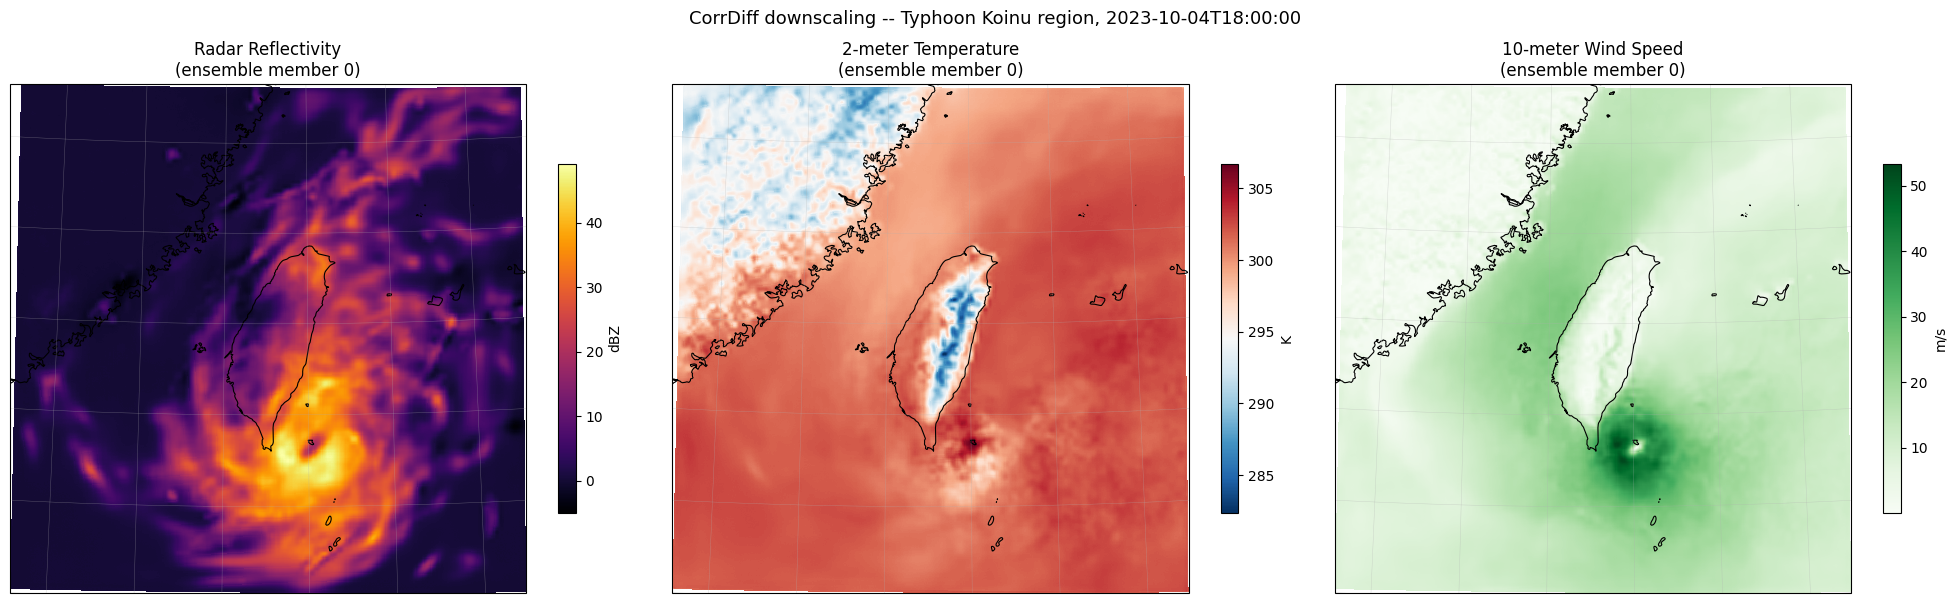

In [9]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

lon_vals = io["lon"][:]
lat_vals = io["lat"][:]
projection = ccrs.LambertConformal(central_longitude=float(np.mean(lon_vals)))

def plot_field(ax, field_2d, cmap, label, title):
    c = ax.pcolormesh(lon_vals, lat_vals, field_2d, transform=ccrs.PlateCarree(), cmap=cmap)
    plt.colorbar(c, ax=ax, shrink=0.65, label=label)
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    ax.set_title(title)

fig = plt.figure(figsize=(20, 6))
member = 0  # first ensemble member -- a single realistic, internally-consistent sample

ax0 = fig.add_subplot(1, 3, 1, projection=projection)
plot_field(ax0, io["mrr"][0, member], "inferno", "dBZ",
           f"Radar Reflectivity\n(ensemble member {member})")

ax1 = fig.add_subplot(1, 3, 2, projection=projection)
plot_field(ax1, io["t2m"][0, member], "RdBu_r", "K",
           f"2-meter Temperature\n(ensemble member {member})")

ax2 = fig.add_subplot(1, 3, 3, projection=projection)
windspeed = np.sqrt(io["u10m"][0, member] ** 2 + io["v10m"][0, member] ** 2)
plot_field(ax2, windspeed, "Greens", "m/s",
           f"10-meter Wind Speed\n(ensemble member {member})")

plt.suptitle(f"CorrDiff downscaling -- Typhoon Koinu region, {CASE_STUDY_TIME}", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("outputs/case_study_single_member.png", dpi=150, bbox_inches="tight")
plt.show()


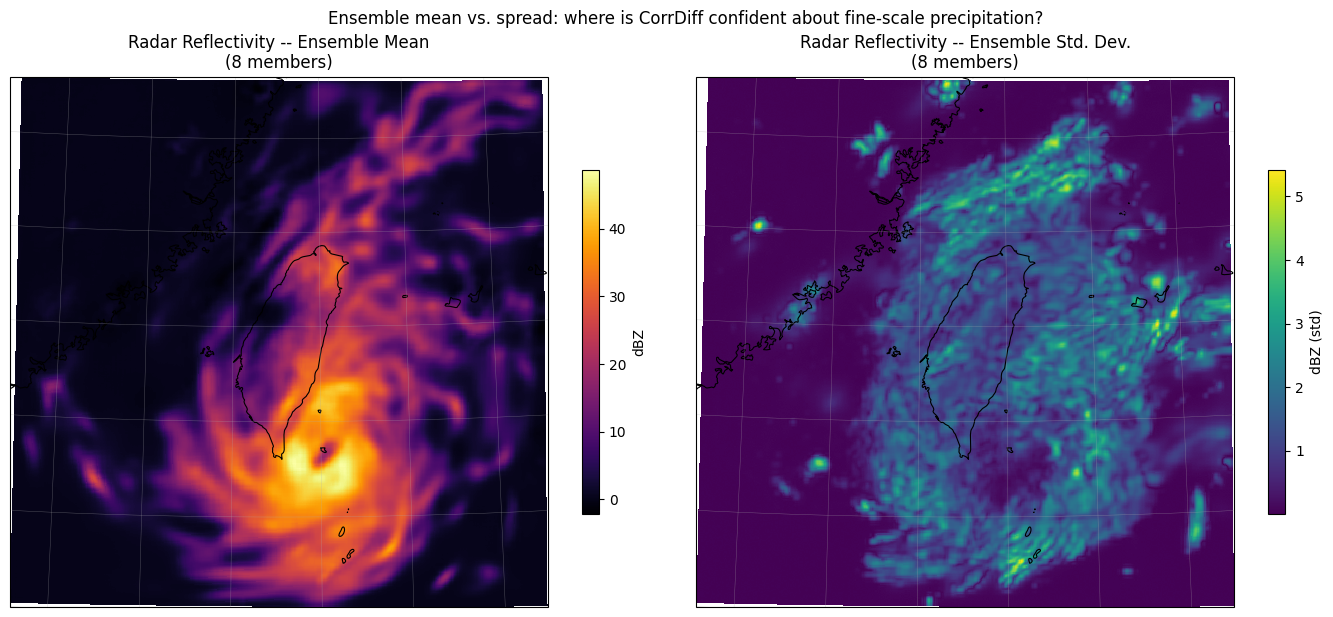

Mean ensemble std-dev across the domain: 0.71 dBZ
Max ensemble std-dev (most uncertain location): 5.42 dBZ

Talking point for your presentation: the std-dev map is highest exactly where
precipitation structure is present in the mean map -- i.e. the model is most
uncertain about the FINE DETAILS of where rain bands sit, even when it's confident
a rain band exists somewhere in that general area. This is the residual-diffusion
component visibly doing its job of representing the irreducibly stochastic part
of km-scale weather, exactly as motivated in Part 1/2 above.


In [10]:
# --- Ensemble mean and spread for radar reflectivity ---
# This is the plot that most directly demonstrates *why* this is a generative
# model and not a regressor: the spread map shows where the model is
# confident vs. uncertain about fine-scale precipitation structure.

mrr_all_members = io["mrr"][0, :]          # shape: (n_samples, lat, lon)
mrr_mean = mrr_all_members.mean(axis=0)
mrr_std = mrr_all_members.std(axis=0)

fig = plt.figure(figsize=(14, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=projection)
plot_field(ax0, mrr_mean, "inferno", "dBZ",
           f"Radar Reflectivity -- Ensemble Mean\n({NUM_ENSEMBLE_MEMBERS} members)")

ax1 = fig.add_subplot(1, 2, 2, projection=projection)
plot_field(ax1, mrr_std, "viridis", "dBZ (std)",
           f"Radar Reflectivity -- Ensemble Std. Dev.\n({NUM_ENSEMBLE_MEMBERS} members)")

plt.suptitle("Ensemble mean vs. spread: where is CorrDiff confident about fine-scale precipitation?", y=1.02)
plt.tight_layout()
plt.savefig("outputs/case_study_ensemble_spread.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean ensemble std-dev across the domain: {mrr_std.mean():.2f} dBZ")
print(f"Max ensemble std-dev (most uncertain location): {mrr_std.max():.2f} dBZ")
print()
print("Talking point for your presentation: the std-dev map is highest exactly where")
print("precipitation structure is present in the mean map -- i.e. the model is most")
print("uncertain about the FINE DETAILS of where rain bands sit, even when it's confident")
print("a rain band exists somewhere in that general area. This is the residual-diffusion")
print("component visibly doing its job of representing the irreducibly stochastic part")
print("of km-scale weather, exactly as motivated in Part 1/2 above.")


### Comparing against the coarse input directly

To make the value of downscaling visually obvious in a slide, it helps to show the raw coarse GFS input side-by-side with the CorrDiff output for the same variable, at the same map extent. The cell below pulls the raw 10m wind components straight from the GFS data source (before they were fed into CorrDiff) and plots them next to the downscaled result.


Fetching GFS data: 100%|██████████| 2/2 [00:00<00:00, 30.78it/s]


2026-06-20 13:54:38.601 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 412051984-953804
2026-06-20 13:54:38.636 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20231004/18/atmos/gfs.t18z.pgrb2.0p25.f000 411076281-975703


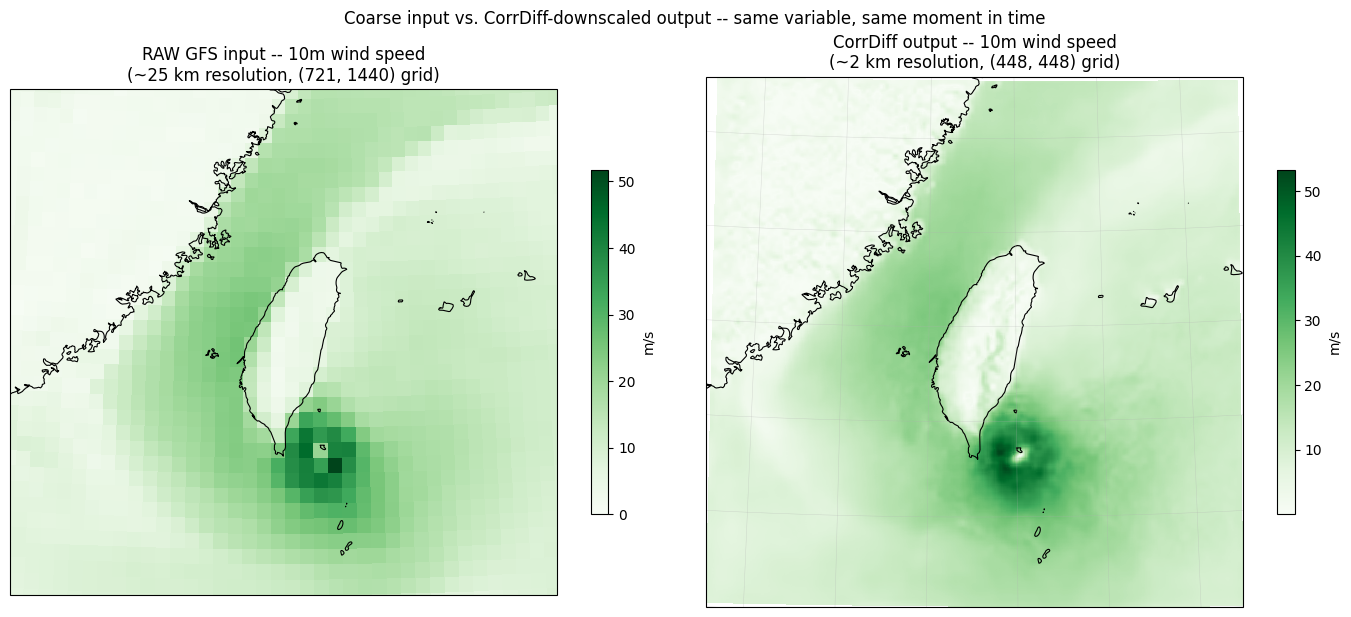

Resolution increase: 0.6x per spatial dimension


In [11]:
# Re-fetch the same GFS snapshot directly (outside the CorrDiff wrapper) purely
# for this comparison plot. Cheap and fast -- it's a small file.
from earth2studio.utils.time import to_time_array

raw_time = to_time_array([CASE_STUDY_TIME])
raw_coarse, raw_coords = prep_data_array(
    data_source(raw_time, ["u10m", "v10m"]), device="cpu"
)
raw_coarse = raw_coarse.numpy()

u10m_coarse = raw_coarse[0, raw_coords["variable"].tolist().index("u10m")]
v10m_coarse = raw_coarse[0, raw_coords["variable"].tolist().index("v10m")]
windspeed_coarse = np.sqrt(u10m_coarse ** 2 + v10m_coarse ** 2)

coarse_lat = raw_coords["lat"]
coarse_lon = raw_coords["lon"]

fig = plt.figure(figsize=(14, 6))

ax0 = fig.add_subplot(1, 2, 1, projection=projection)
c0 = ax0.pcolormesh(coarse_lon, coarse_lat, windspeed_coarse,
                     transform=ccrs.PlateCarree(), cmap="Greens", vmin=0)
plt.colorbar(c0, ax=ax0, shrink=0.65, label="m/s")
ax0.coastlines(resolution="10m", linewidth=0.8)
ax0.set_extent([float(lon_vals.min()), float(lon_vals.max()),
                float(lat_vals.min()), float(lat_vals.max())], crs=ccrs.PlateCarree())
ax0.set_title(f"RAW GFS input -- 10m wind speed\n(~25 km resolution, {windspeed_coarse.shape} grid)")

ax1 = fig.add_subplot(1, 2, 2, projection=projection)
plot_field(ax1, windspeed, "Greens",
           "m/s", f"CorrDiff output -- 10m wind speed\n(~2 km resolution, {windspeed.shape} grid)")

plt.suptitle("Coarse input vs. CorrDiff-downscaled output -- same variable, same moment in time", y=1.02)
plt.tight_layout()
plt.savefig("outputs/case_study_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Resolution increase: {windspeed.shape[0] / windspeed_coarse.shape[0]:.1f}x per spatial dimension")


---
## Part 9 — Summary for your presentation

### Key numbers to put on a slide

| Metric | Value |
|---|---|
| Input resolution | ~25 km (ERA5 in the paper; GFS in this demo) |
| Output resolution | ~2 km |
| Resolution gain | 12.5× per spatial dimension |
| Input channels | 12 (single-level + 850/500 hPa pressure-level variables) |
| Output channels | 4 (incl. one *synthesized* channel — radar reflectivity — not present in the input) |
| Model size | ~80M parameters (UNet, used twice: regression + diffusion) |
| Training compute | 128× H100 GPUs, 7 days, ≈21,504 GPU-hours |
| Training data | ~24,000 hourly samples, 3 years (2018–2020), one region |
| Inference compute (single sample) | ~0.18 sec on one H100 (paper's benchmark); fast enough for a free-tier Colab T4 in this notebook |
| Speed-up vs. the physical WRF simulation it emulates | ~22–500× faster (depending on exact comparison), ~1,300–10,000× more energy-efficient |

### Key talking points

1. **The core idea — decompose into mean + residual** — is broadly transferable. Any "replace expensive physical simulation with a cheap learned mapping" project can ask: does the target distribution have a learnable, low-variance mean? If so, predicting it with cheap regression and reserving the expensive generative model only for the *residual* could make training and inference dramatically more efficient — this is a design pattern, not a Taiwan-specific or weather-specific trick.
2. **Generative ≠ "fancier regression."** The entire point of using a diffusion model here is to produce calibrated, sharp, *individually realistic* samples and a genuine notion of uncertainty (ensemble spread) — something an MSE-trained network is mathematically incapable of doing well, regardless of how large you make it. This is the single most important conceptual point to land with a research audience evaluating GenAI as a replacement for physical models.
3. **The hardware story has two very different chapters.** Training is a serious data-center undertaking (128 H100s for a week). Inference is cheap enough to run on a single free-tier Colab GPU. Any planning discussion about adopting GenAI weather models needs to keep these two cost structures separate — a model that's prohibitively expensive to train can still be cheap and practical to deploy once trained, exactly the situation here and (per your project notes) the inverse of the situation with FourCastNet3's inference-time memory requirements.
4. **Known limitations**, worth stating honestly to a research audience: model calibration is imperfect (the paper finds the ensemble is somewhat *under-dispersive* — real-world variability is larger than the ensemble spread suggests), and tropical cyclone size/intensity corrections are only partial. These are exactly the kind of caveats domain scientists will appreciate you raising rather than glossing over.

### Where to go from here

- Try a different case study date — the WRF target data spans 2018–2021, and the paper's own additional case studies cover frontal systems and the 2021 typhoon Chanthu, if you want a second example with different characteristics (a frontal system instead of a typhoon, e.g.)
- Increase `NUM_ENSEMBLE_MEMBERS` toward the paper's 32 if you want smoother ensemble-spread maps (linear cost increase — expect proportionally longer runtime, still fast on a T4)
- The model is region-locked to Taiwan (that's what it was trained on) — note this clearly if your audience asks whether this exact checkpoint could be pointed at India. It could not, without retraining on Indian regional target data (which would require an equivalent of CWA's high-resolution WRF archive for an Indian region) — this is worth flagging explicitly since your project is specifically about applicability to India.
